# Get DEM parameter

Aspect, slope, concavity? 

Should I do this in bash? 

In [1]:
# calculate gradient, aspect from DEM
import numpy as np
import rioxarray as rxa
from rasterio.enums import Resampling
import matplotlib.pyplot as plt
from osgeo import gdal
import rasterio

/Users/julo9057/anaconda3/envs/snowex_uavsar_coherence/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
qsi_dir = '../data/snowex_lowman/snex_qsi_lidar/'
out_dir = '../data/snowex_lowman/dem_params/'
data_dir = '../data/snowex_lowman/'

In [3]:
# load dem
dem_fp = qsi_dir + 'SNEX20_QSI_DEM_0.5M_USIDMC_20210917_20210917.tif'
res = 5  # desired resolution in meters
dem_raw = rxa.open_rasterio(dem_fp)
resampled_dem = dem_raw.rio.reproject(dem_raw.rio.crs, resampling=Resampling.average, resolution=(res, res))
dem = resampled_dem.rio.reproject('EPSG:4326')
dem = dem.squeeze()  # remove band dimension
dem = dem.where(dem != dem.rio.nodata)  # set nodata values to NaN

In [25]:
# produce aspect and slope rasters
gdal.DEMProcessing(out_dir + 'mores_creek_slope.tif', dem_fp, 'slope', outputSRS='EPSG:4326')
gdal.DEMProcessing(out_dir + 'mores_creek_aspect.tif', dem_fp, 'aspect', outputSRS='EPSG:4326')

/Users/julo9057/anaconda3/envs/snowex_uavsar_coherence/lib/python3.13/site-packages/osgeo/gdal.py:330: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


TypeError: DEMProcessingOptions() got an unexpected keyword argument 'outputSRS'

In [4]:
# calculate gradient for each pixel 

# Calculate slope using GDAL
# gdal.DEMProcessing(out_dir + 'mores_creek_slope.tif', dem_fp, 'slope')

# Read the calculated slope into a NumPy array
with rasterio.open(out_dir + 'slope.tif') as dataset:
    slope = dataset.read(1)

# You can similarly calculate aspect
# gdal.DEMProcessing(out_dir + 'aspect.tif', dem_fp, 'aspect')
with rasterio.open(out_dir + 'aspect.tif') as dataset:
    aspect = dataset.read(1)

print(f"Slope data type: {slope.dtype}")
print(f"Slope array shape: {slope.shape}")


Slope data type: float32
Slope array shape: (16810, 15747)


In [52]:
slope_orig = rxa.open_rasterio(out_dir + 'slope.tif').squeeze()
# print(slope_orig)
slope_raw = dem_raw.squeeze().copy(data=slope_orig)
resampled_slope = slope_raw.rio.reproject(slope_raw.rio.crs, resampling=Resampling.average, resolution=(res, res))
slope = resampled_slope.rio.reproject('EPSG:4326')
slope = slope.squeeze()  # remove band dimension
slope = slope.where(slope != slope.rio.nodata)  # set nodata values to NaN
slope = slope.where(slope != -9999)
# print(slope)

aspect_orig = rxa.open_rasterio(out_dir + 'aspect.tif').squeeze()
# print(aspect_orig)
aspect_raw = dem_raw.squeeze().copy(data=aspect_orig)
resampled_aspect = aspect_raw.rio.reproject(aspect_raw.rio.crs, resampling=Resampling.average, resolution=(res, res))
aspect = resampled_aspect.rio.reproject('EPSG:4326')
aspect = aspect.squeeze()  # remove band dimension
aspect = aspect.where(aspect != aspect.rio.nodata)  # set nodata values to NaN
aspect = aspect.where(aspect != -9999)
# treat < 0 or > 360 as nan
# aspect = aspect.where(aspect < 0, np.nan)
# aspect = aspect.where(aspect > 360, np.nan)
# print(aspect)

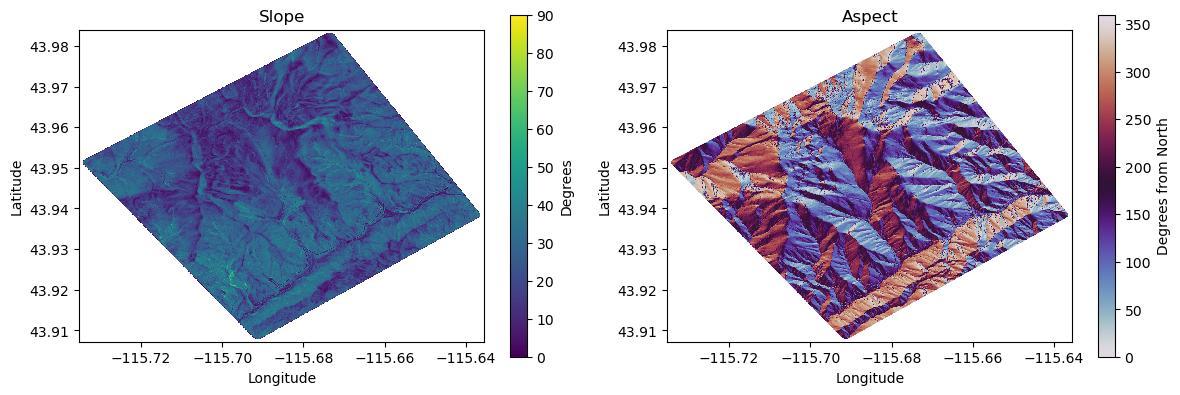

In [53]:
# plot slope and aspect 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# slope_ds = slope.isel(x=slice(None, None, 10), y=slice(None, None, 10))
slope_img = slope.plot(ax=ax1, vmin=0, vmax=90, cmap='viridis', add_colorbar=False)
ax1.set_title('Slope')
fig.colorbar(slope_img, ax=ax1, orientation='vertical', label='Degrees', shrink=0.6)
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')

aspect_img = aspect.plot(ax=ax2, vmin=0, vmax=360, cmap='twilight', add_colorbar=False)
ax2.set_title('Aspect')
fig.colorbar(aspect_img, ax=ax2, orientation='vertical', label='Degrees from North', shrink=0.6)
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')

ax1.set_aspect('equal')
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

In [54]:
# write the resampled slope and aspect tifs to file
import rasterio

out_dir = '../data/snowex_lowman/dem_params/'
out_fp = "MCS_slope_5m.tif"
height, width = slope.shape
transform = slope.rio.transform()
crs = slope.rio.crs

with rasterio.open(
    out_dir + out_fp,
    'w',
    driver='GTiff',
    height=height,
    width=width,
    count=1,
    dtype='float32',
    crs=crs,
    transform=transform,
    nodata=np.nan,
) as dst:
    dst.write(slope.astype('float32'), 1)

out_fp = "MCS_aspect_5m.tif"
height, width = aspect.shape
transform = aspect.rio.transform()
crs = aspect.rio.crs

with rasterio.open(
    out_dir + out_fp,
    'w',
    driver='GTiff',
    height=height,
    width=width,
    count=1,
    dtype='float32',
    crs=crs,
    transform=transform,
    nodata=np.nan,
) as dst:
    dst.write(aspect.astype('float32'), 1)